In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

# Aumenta o tamanho das figuras (gráficos)
plt.rcParams['figure.dpi'] = 150
# Aumenta a largura do JupyterNotebook
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:65% !important; }</style>"))

from IPython.display import display, Markdown



## Dados Incidentes
<br>

#### Esse notebook é continuação da limpeza de dados feita no arquivo risco_acidente_offshore.ipynb.

In [44]:
df = pd.read_feather("incidents_final_enriched_LIMPO.feather")
df

,Numero,CNPJ,Instalacao,Tipo_Instalacao_Detalhado,Proprietario_Instalacao,Fonte_Classificacao,Data_de_criacao,DataHora_primeira_observacao,DataHora_incidente,Tipo_de_incidente,Categoria_Custo,Custo_Incidente,DSC_GRAVIDADE_TIPO,DSC_QUASE_ACIDENTE_ACIDENTE,Numero_de_feridos_graves,Numero_de_fatalidades
0,1307/000022,08926302000105,Ocean Quest,Navio de apoio logístico,Não identificado,Classificação avançada (confiança: Média) - Fr...,2013-07-09,2013-06-26 18:20:00,2013-06-26 18:20:00,SSM - Ferimento grave,Danos a Saúde,249750.0,MODERADO,Acidente,1,0
1,1307/000023,33000167000101,Cerrado,Outro,Não identificado,Classificação avançada (confiança: Muito Baixa...,2013-07-10,2013-07-06 07:20:00,2013-07-06 07:20:00,SSM - Ferimento grave,Danos a Saúde,249750.0,MODERADO,Acidente,1,0
2,1307/000025,33000167000101,Ocean-Rig Corcovado,Sonda de Perfuração,Ocean Rig,https://pt.linkedin.com/posts/venicio-viter-a7...,2013-07-11,2013-07-09 12:45:00,2013-07-09 12:45:00,SSM - Princípio de incêndio,Danos a Equipamentos,45000.0,LEVE,Acidente,0,0
3,1307/000026,33000167000101,OCEAN ALLIANCE,Navio de apoio logístico,Não identificado,Classificação avançada (confiança: Média) - Fr...,2013-07-11,2013-07-09 18:20:00,2013-07-09 18:20:00,SSM - Ferimento grave,Danos a Saúde,249750.0,MODERADO,Acidente,1,0
4,1307/000027,33000167000101,SS AMAZÔNIA,Sonda de perfuração,Baerfield Drilling LLC,https://www.gov.br/mme/pt-br/arquivos/do-29-09...,2013-07-12,2013-06-28 16:30:00,2013-06-28 16:30:00,SSM - Descarga menor de óleo,Custos Ambientais,3000.0,LEVE,Acidente,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25641,2309/000219,09347916000197,FPSO CIDADE DE ITAJAÍ,FPSO,SBM Offshore (afretado pela Petrobras),https://www.sbmoffshore.com/,2023-09-29,2023-05-29 10:35:00,2023-05-29 10:35:00,SSM - Falha estrutural em tanque,Danos a Equipamentos,22500000.0,GRAVE,Acidente,0,0
25642,2309/000219,09347916000197,FPSO CIDADE DE ITAJAÍ,FPSO,SBM Offshore (afretado pela Petrobras),https://www.sbmoffshore.com/,2023-09-29,2023-05-29 10:35:00,2023-05-29 10:35:00,SSM - Perda de contenção primária maior de águ...,Custos Ambientais,3000.0,LEVE,Quase acidente,0,0
25643,2501/000230,35723994000159,SÃO MATEUS LESTE,Outro,Não identificado,Classificação avançada (confiança: Muito Baixa...,2025-01-30,2023-06-05 08:00:00,2023-06-05 07:50:00,SSM - Descarga significante de óleo,Custos Ambientais,252500.0,MODERADO,Acidente,0,0
25644,2501/000230,35723994000159,SÃO MATEUS LESTE,Outro,Não identificado,Classificação avançada (confiança: Muito Baixa...,2025-01-30,2023-06-05 08:00:00,2023-06-05 07:50:00,SSM - Perda de contenção primária significante...,Custos Ambientais,3000.0,LEVE,Quase acidente,0,0


## Hora do Incidente

#### De acordo com os dados apresentados, a maioria dos incidentes acontecem por volta das 10 horas da manhã e depois um outro pico por volta das 16 horas da tarde, se for levar em conta que o maquinário trabalha 24 horas por dia, é possível supor que a maioria dos incidentes são de causa humana no momento de inicio e fim de expediente.

In [45]:
# Criando tabela para criar os gráficos de tempo por quantidade de incidentes
tabela = df.pivot_table(
    index=df['DataHora_incidente'].dt.year,
    columns=df['DataHora_incidente'].dt.hour,
    values='DataHora_incidente',
    aggfunc='count',
    fill_value=0
)

# Ordenando os valores
tabela_sorted = tabela.sort_index(ascending=False)
tabela_sorted

DataHora_incidente,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
DataHora_incidente,,,,,,,,,,,,,,,,,,,,,
2023,63,41,40,33,45,36,43,49,93,93,...,97,103,85,71,54,42,52,33,40,30
2022,75,44,56,46,52,53,57,100,161,190,...,207,233,177,132,79,77,54,76,66,51
2021,95,49,64,36,55,58,74,112,186,204,...,219,227,215,174,85,63,54,73,76,46
2020,82,54,49,47,52,70,51,84,122,124,...,125,120,133,101,78,44,62,64,64,68
2019,94,59,89,79,59,72,71,95,121,140,...,164,151,174,150,109,79,81,86,81,86
2018,78,54,67,47,66,63,65,78,135,154,...,115,134,137,120,94,78,87,69,57,67
2017,65,49,53,63,69,69,84,80,139,142,...,141,143,150,122,98,63,76,74,71,72
2016,58,56,97,61,56,83,96,150,204,232,...,221,201,247,185,99,82,75,86,66,64
2015,53,37,79,56,46,63,102,98,129,163,...,172,170,174,135,97,71,77,78,80,56


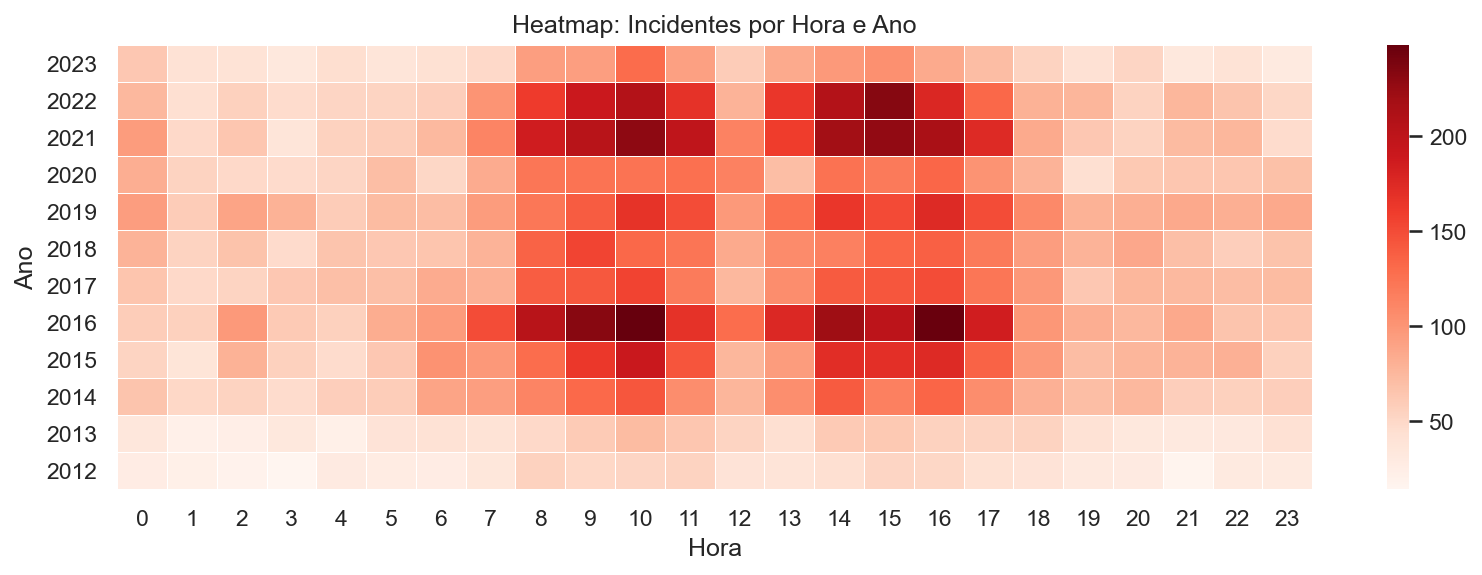

In [46]:
plt.figure(figsize=(11, 4))

sns.heatmap(
    tabela_sorted,
    cmap='Reds',
    linewidths=0.3,
    linecolor='white'
)

plt.title('Heatmap: Incidentes por Hora e Ano')
plt.xlabel('Hora')
plt.ylabel('Ano')
plt.tight_layout()

# Pega a figura atual e salva
fig = plt.gcf()
fig.savefig(
    "graficos/Heatmap_Incidentes_por_Hora_e_Ano.png", 
    dpi=600, 
    bbox_inches='tight', 
    transparent=True
)


plt.show()
plt.close()  # Fecha a figura para não duplicar

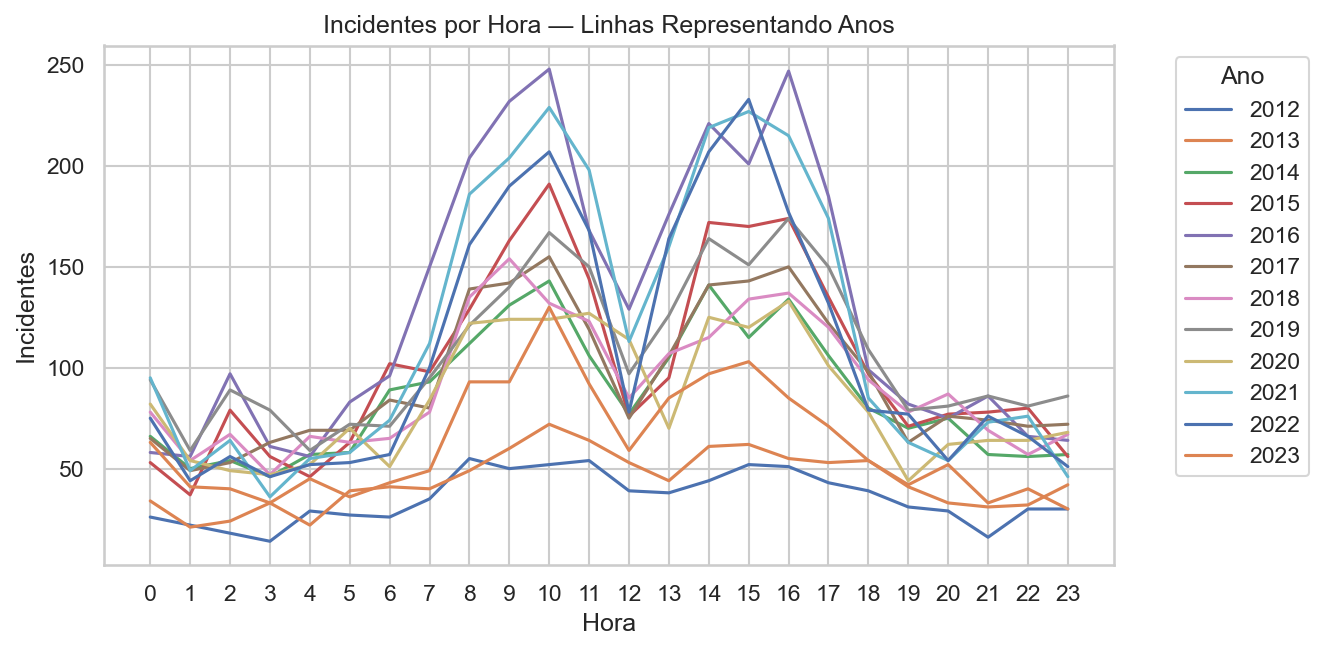

In [47]:


# Garantir que as colunas (horas) estejam em ordem crescente
tabela = tabela.sort_index(axis=1)

plt.figure(figsize=(9,4.5))

for ano in tabela.index:
    y = tabela.loc[ano].values          # garante 1D
    x = tabela.columns.values.astype(int)  # horas como array 1D
    plt.plot(x, y, label=str(ano))

plt.xlabel('Hora')
plt.ylabel('Incidentes')
plt.title('Incidentes por Hora — Linhas Representando Anos')

# ticks de x em x horas
plt.xticks(range(0, 24, 1))

plt.legend(title='Ano', bbox_to_anchor=(1.05,1))
plt.tight_layout()

# Salvar em arquivo
#plt.savefig("graficos/Incidentes por Hora — Linhas Representando Anos.png", dpi=600, bbox_inches='tight')
fig = plt.gcf()
fig.savefig(
    "graficos/Incidentes por Hora — Linhas Representando Anos.png", 
    dpi=600, 
    bbox_inches='tight', 
    transparent=True
)

plt.show()
plt.close()  # Fecha a figura para não duplicar

In [48]:
top3_horas = tabela.apply(
    lambda linha: linha.nlargest(3).index.tolist(),
    axis=1,
    result_type='expand'
)

top3_horas.columns = ['hora_1', 'hora_2', 'hora_3']
top3_horas

,hora_1,hora_2,hora_3
DataHora_incidente,,,
2012,8,11,10
2013,10,11,15
2014,10,14,16
2015,10,16,14
2016,10,16,9
2017,10,16,15
2018,9,16,8
2019,16,10,14
2020,16,11,14


## Tipo de Instalação

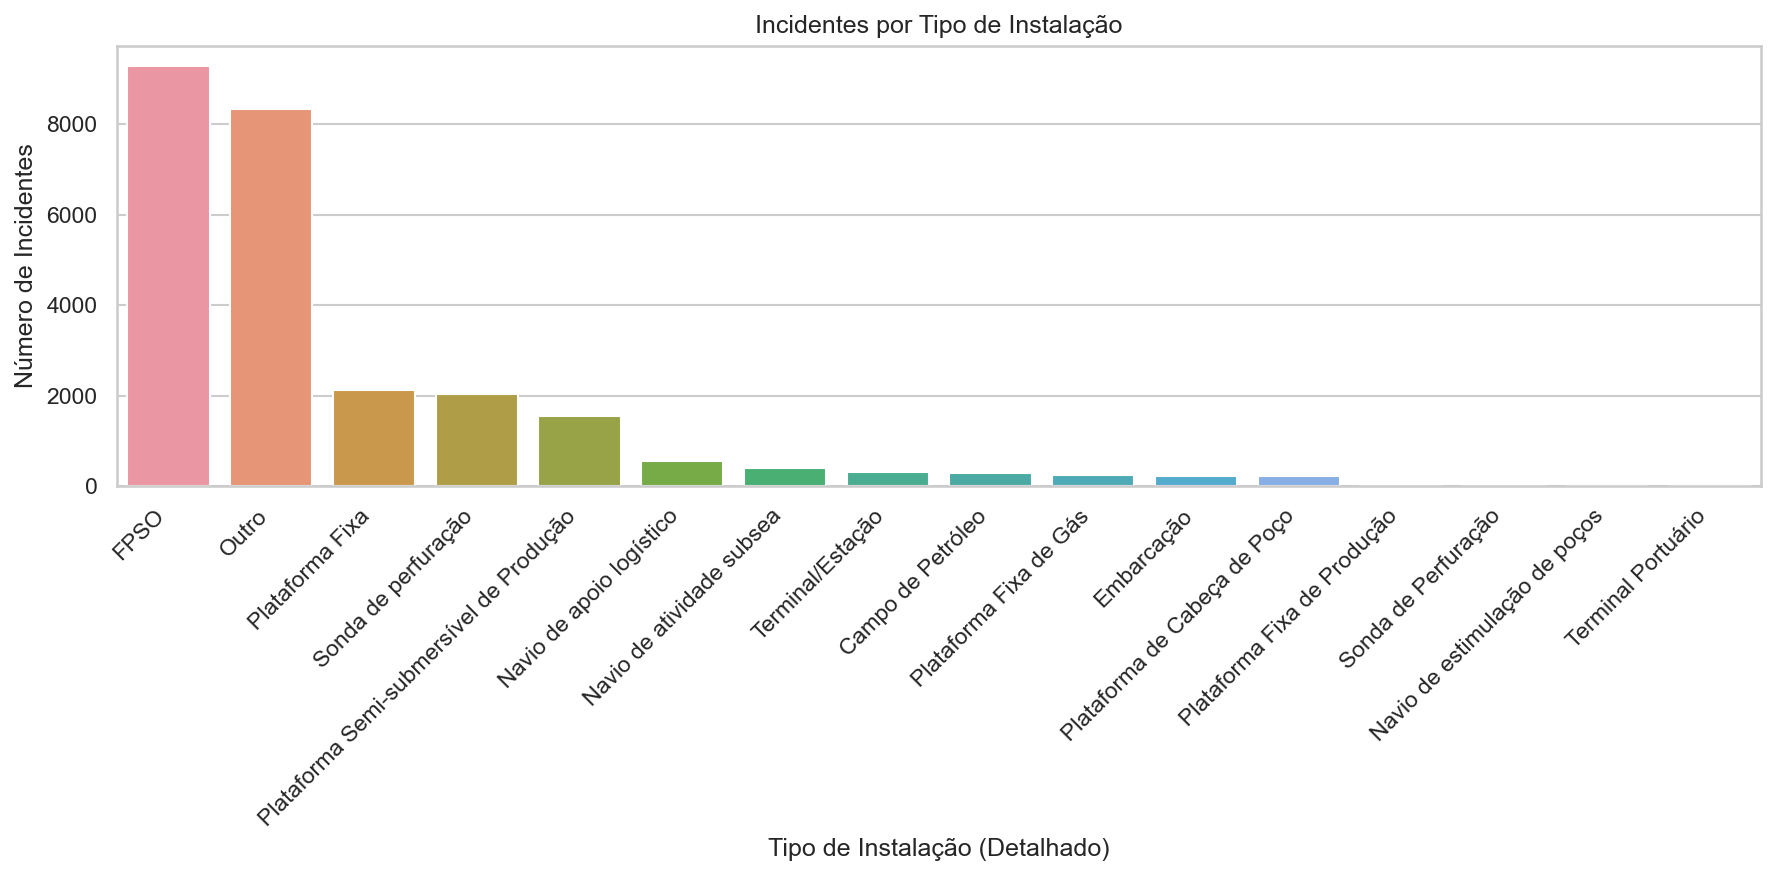

In [66]:
contagem = df['Tipo_Instalacao_Detalhado'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=contagem.index, y=contagem.values)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Tipo de Instalação (Detalhado)')
plt.ylabel('Número de Incidentes')
plt.title('Incidentes por Tipo de Instalação')
plt.tight_layout()

# Salvar em arquivo
#plt.savefig("graficos/Incidentes por Tipo de Instalação.png", dpi=600, bbox_inches='tight')

fig = plt.gcf()
fig.savefig(
    "graficos/Incidentes por Tipo de Instalação.png", 
    dpi=600, 
    bbox_inches='tight', 
    transparent=True
)

plt.show()
plt.close()  # Fecha a figura para não duplicar

## Tipo de Incidente

In [50]:
# Filtrar para remover "Informação não padronizada"
df_filtrado = df[df['Tipo_de_incidente'] != 'Informação não padronizada'].copy()

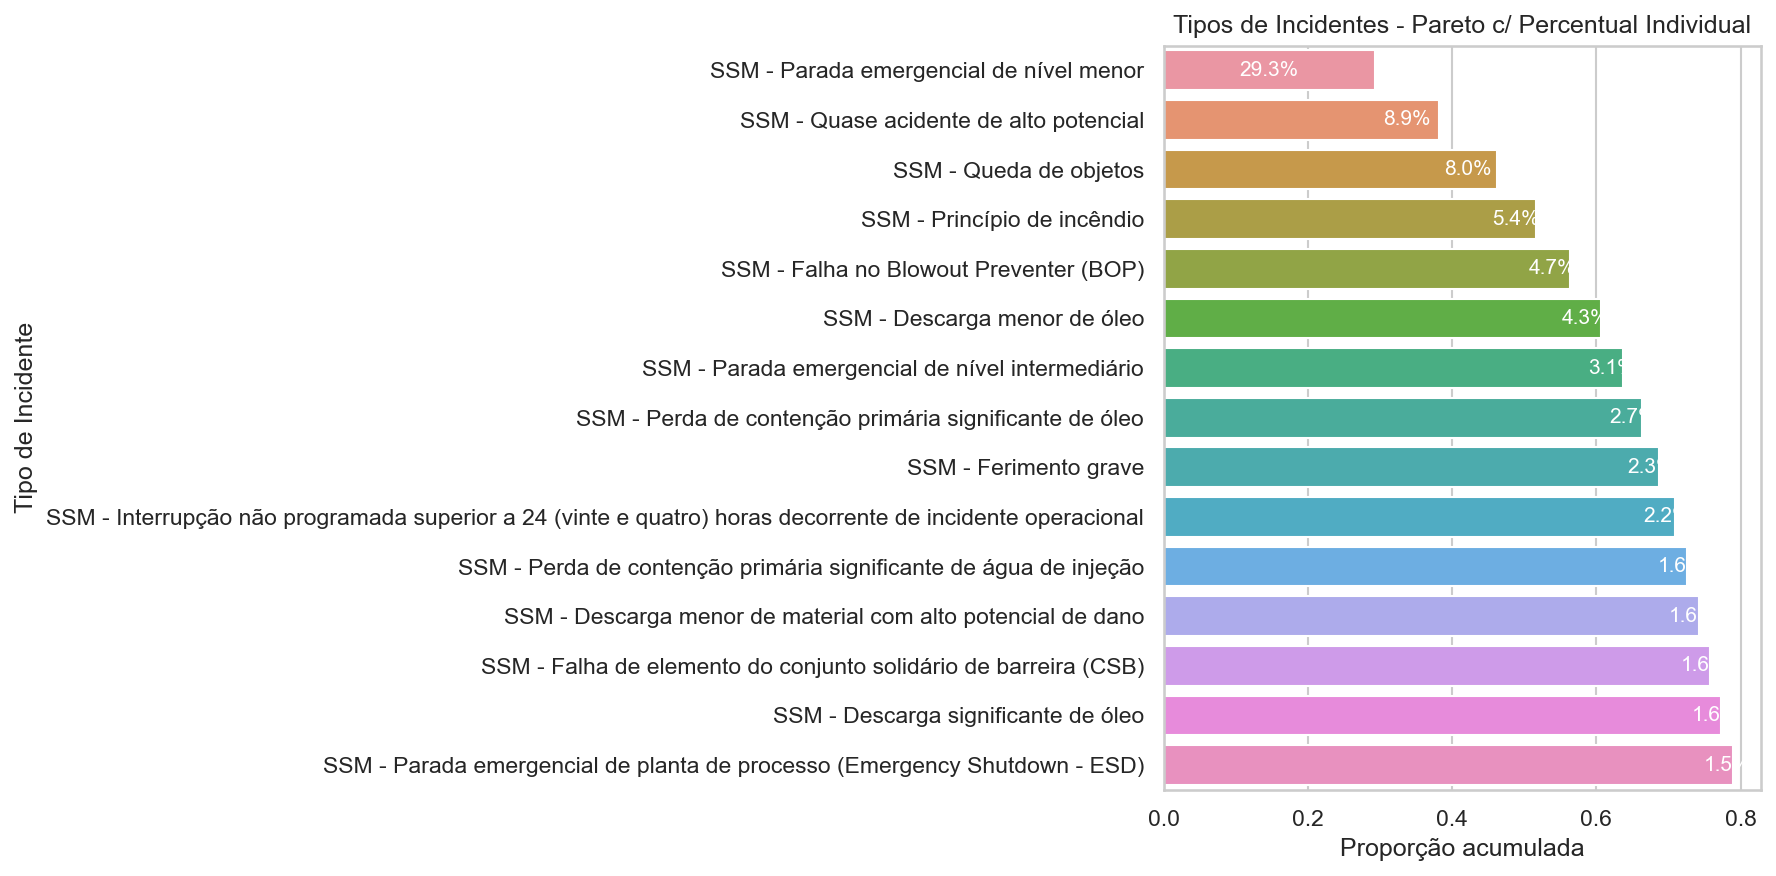

In [67]:
# cálculo normal do pareto
contagem = df_filtrado['Tipo_de_incidente'].value_counts()
percentual = contagem / contagem.sum()
acumulado = percentual.cumsum()

# mantém itens até 80%
pareto = acumulado[acumulado <= 0.8]

# gráfico do acumulado
plt.figure(figsize=(12, 6))
sns.barplot(
    x=pareto.values,   # valores ACUMULADOS
    y=pareto.index
)

# adiciona valores INDIVIDUAIS dentro das barras
for i, categoria in enumerate(pareto.index):
    valor_individual = percentual[categoria]  # percentual individual
    valor_acumulado = pareto[categoria]       # percentual acumulado (tamanho da barra)

    plt.text(
        valor_acumulado - (valor_individual / 2),  # coloca o texto no meio da parte da barra correspondente ao item
        i,
        f"{valor_individual:.1%}",                 # mostra o percentual individual
        ha='center',
        va='center',
        color='white',
        fontsize=10
    )

plt.xlabel('Proporção acumulada')
plt.ylabel('Tipo de Incidente')
plt.title('Tipos de Incidentes - Pareto c/ Percentual Individual')
plt.tight_layout()

# Salvar em arquivo
#plt.savefig("graficos/Tipos de Incidentes - Pareto c Percentual Individual.png", dpi=600, bbox_inches='tight')

fig = plt.gcf()
fig.savefig(
    "graficos/Tipos de Incidentes - Pareto c Percentual Individual.png", 
    dpi=600, 
    bbox_inches='tight', 
    transparent=True
)

plt.show()
plt.close()  # Fecha a figura para não duplicar

## Gravidade do Incidente

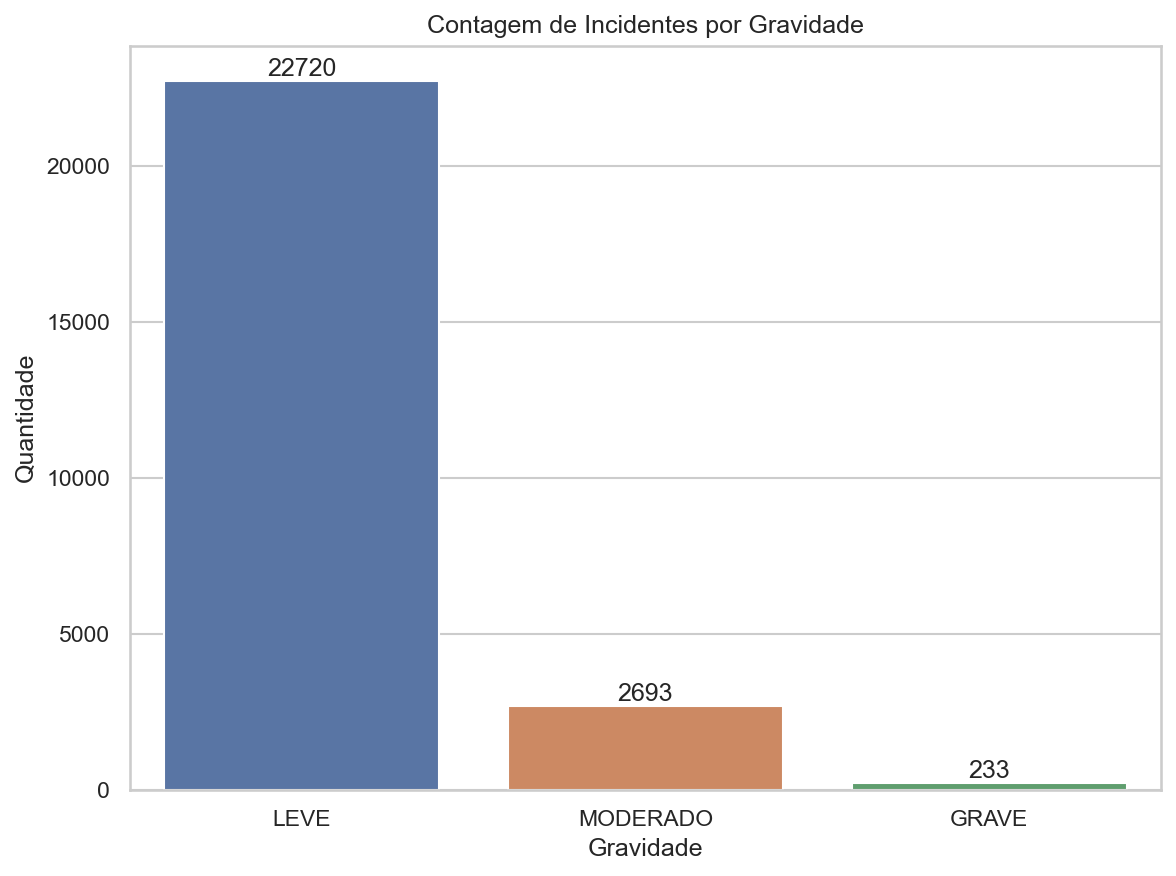

In [68]:
contagem = df['DSC_GRAVIDADE_TIPO'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=contagem.index, y=contagem.values)

plt.xlabel('Gravidade')
plt.ylabel('Quantidade')
plt.title('Contagem de Incidentes por Gravidade')

# valores no topo
for i, v in enumerate(contagem.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()

# Salvar em arquivo
#plt.savefig("graficos/Contagem de Incidentes por Gravidade.png", dpi=600, bbox_inches='tight')

fig = plt.gcf()
fig.savefig(
    "graficos/Contagem de Incidentes por Gravidade.png", 
    dpi=600, 
    bbox_inches='tight', 
    transparent=True
)

plt.show()


### Gravidade LEVE por tipo de Incidente

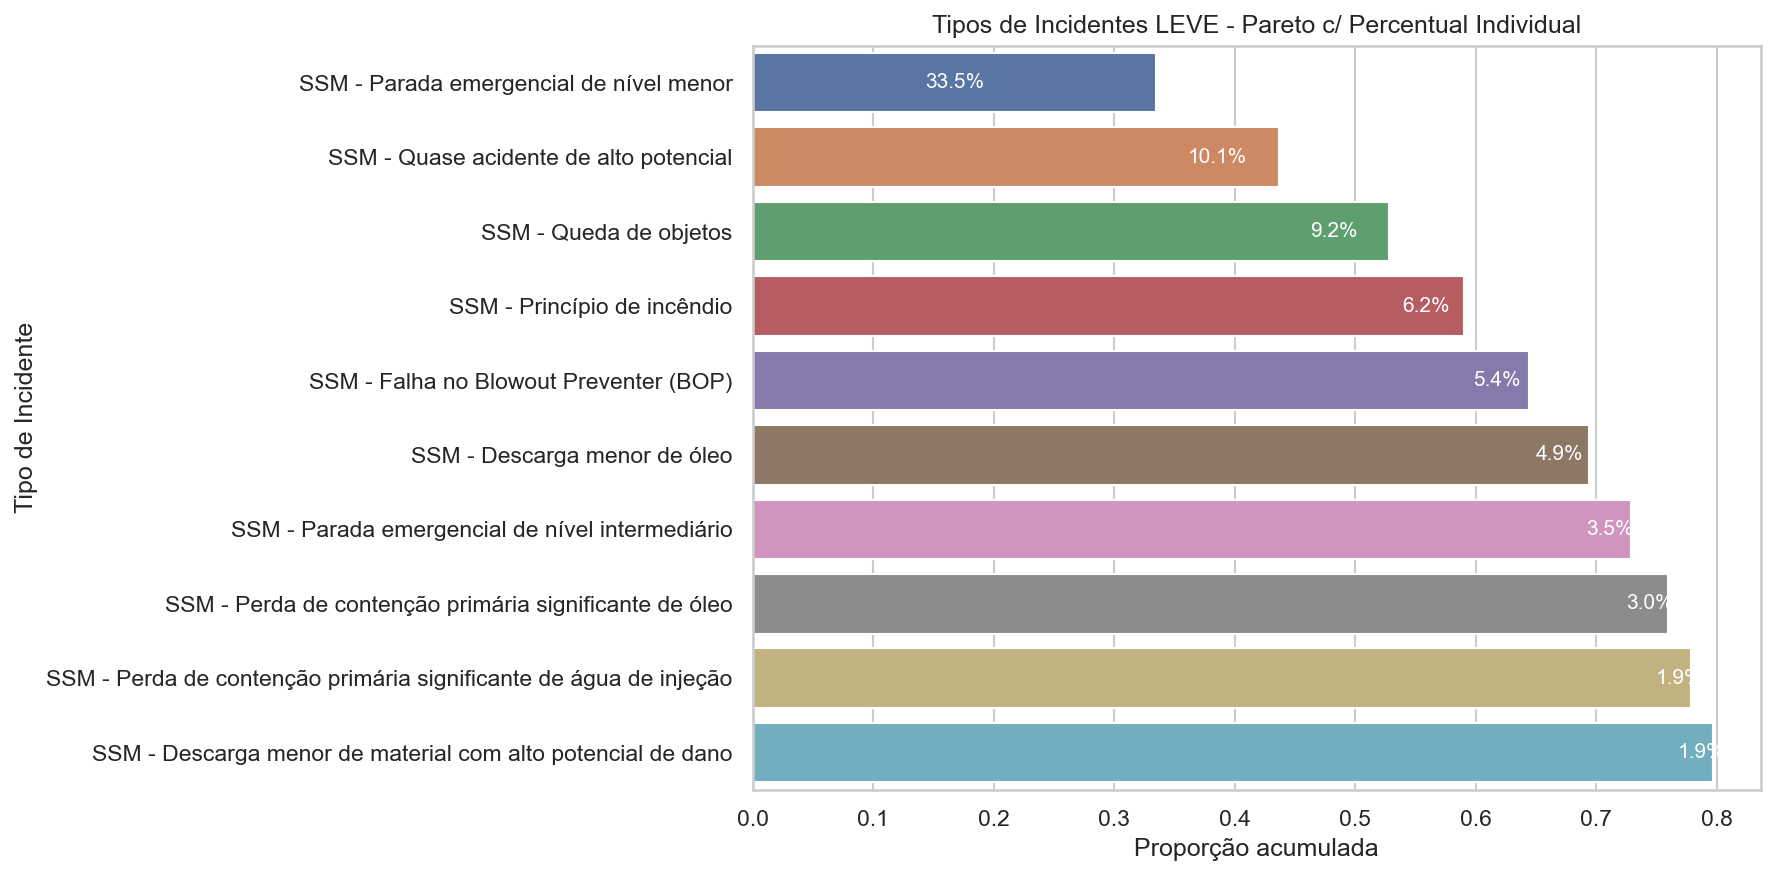

In [69]:
df_leve = df_filtrado[df_filtrado["DSC_GRAVIDADE_TIPO"] == "LEVE"]

contagem = df_leve['Tipo_de_incidente'].value_counts()
percentual = contagem / contagem.sum()
acumulado = percentual.cumsum()

pareto = acumulado[acumulado <= 0.8]

plt.figure(figsize=(12, 6))
sns.barplot(
    x=pareto.values,   # acumulado
    y=pareto.index
)

for i, categoria in enumerate(pareto.index):
    valor_individual = percentual[categoria]
    valor_acumulado = pareto[categoria]

    plt.text(
        valor_acumulado - (valor_individual / 2),
        i,
        f"{valor_individual:.1%}",
        ha='center',
        va='center',
        color='white',
        fontsize=10
    )

plt.xlabel('Proporção acumulada')
plt.ylabel('Tipo de Incidente')
plt.title('Tipos de Incidentes LEVE - Pareto c/ Percentual Individual')
plt.tight_layout()

# Salvar em arquivo
#plt.savefig("graficos/Tipos de Incidentes LEVE - Pareto c Percentual Individual.png", dpi=600, bbox_inches='tight')

fig = plt.gcf()
fig.savefig(
    "graficos/Tipos de Incidentes LEVE - Pareto c Percentual Individual.png", 
    dpi=600, 
    bbox_inches='tight', 
    transparent=True
)

plt.show()

### Gravidade MODERADA por tipo de Incidente

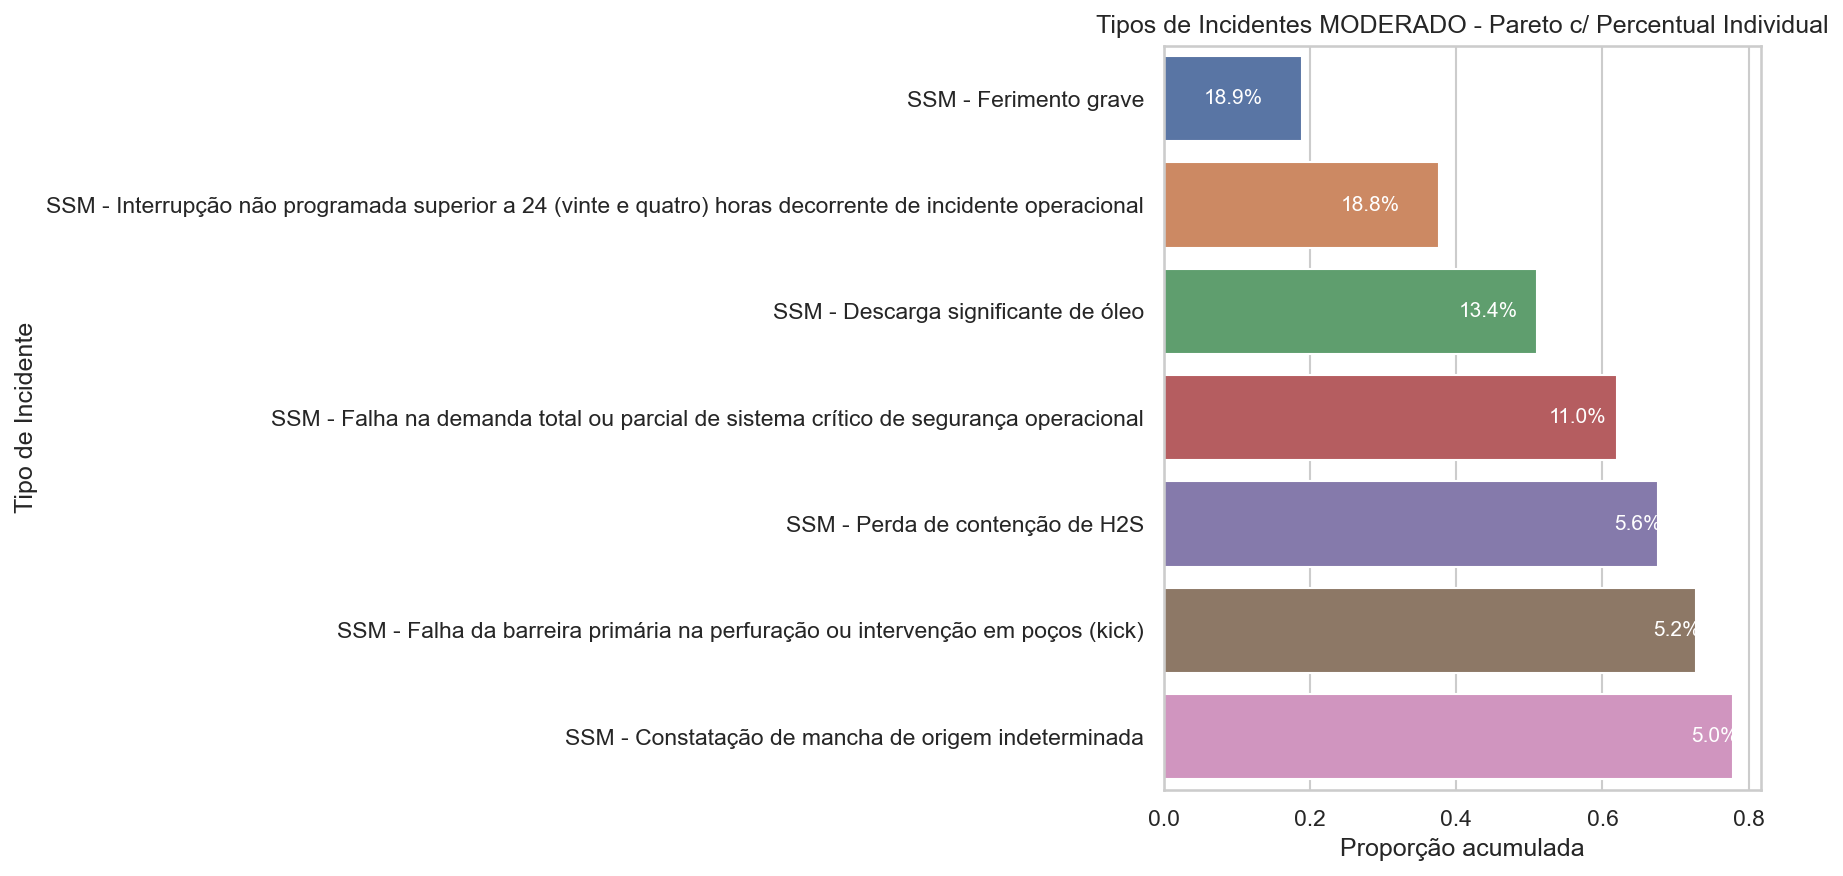

In [70]:
df_moderado = df_filtrado[df_filtrado["DSC_GRAVIDADE_TIPO"] == "MODERADO"]

contagem = df_moderado['Tipo_de_incidente'].value_counts()
percentual = contagem / contagem.sum()
acumulado = percentual.cumsum()

pareto = acumulado[acumulado <= 0.8]

plt.figure(figsize=(12, 6))
sns.barplot(
    x=pareto.values,
    y=pareto.index
)

for i, categoria in enumerate(pareto.index):
    valor_individual = percentual[categoria]
    valor_acumulado = pareto[categoria]

    plt.text(
        valor_acumulado - (valor_individual / 2),
        i,
        f"{valor_individual:.1%}",
        ha='center',
        va='center',
        color='white',
        fontsize=10
    )

plt.xlabel('Proporção acumulada')
plt.ylabel('Tipo de Incidente')
plt.title('Tipos de Incidentes MODERADO - Pareto c/ Percentual Individual')
plt.tight_layout()

# Salvar em arquivo
#plt.savefig("graficos/Tipos de Incidentes MODERADO - Pareto c Percentual Individual.png", dpi=600, bbox_inches='tight')

fig = plt.gcf()
fig.savefig(
    "graficos/Tipos de Incidentes MODERADO - Pareto c Percentual Individual.png", 
    dpi=600, 
    bbox_inches='tight', 
    transparent=True
)

plt.show()

### Gravidade GRAVE por tipo de Incidente

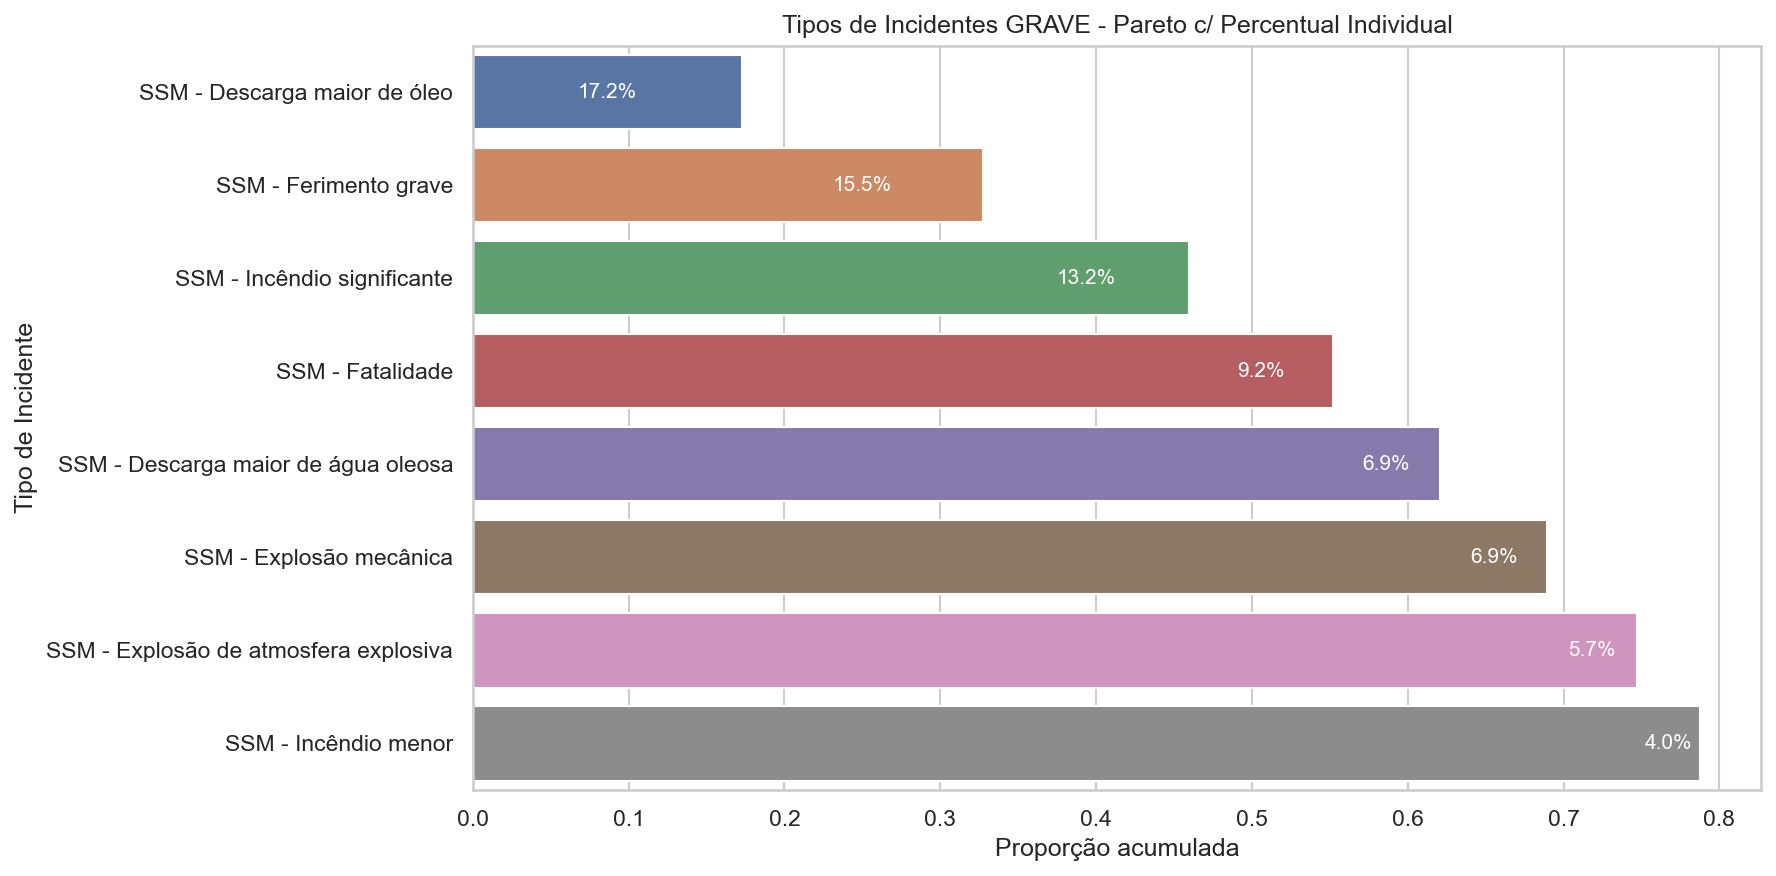

In [78]:
df_grave = df_filtrado[df_filtrado["DSC_GRAVIDADE_TIPO"] == "GRAVE"]

contagem = df_grave['Tipo_de_incidente'].value_counts()
percentual = contagem / contagem.sum()
acumulado = percentual.cumsum()

pareto = acumulado[acumulado <= 0.8]

plt.figure(figsize=(12, 6))
sns.barplot(
    x=pareto.values,
    y=pareto.index
)

for i, categoria in enumerate(pareto.index):
    valor_individual = percentual[categoria]
    valor_acumulado = pareto[categoria]

    plt.text(
        valor_acumulado - (valor_individual / 2),
        i,
        f"{valor_individual:.1%}",
        ha='center',
        va='center',
        color='white',
        fontsize=10
    )

plt.xlabel('Proporção acumulada')
plt.ylabel('Tipo de Incidente')
plt.title('Tipos de Incidentes GRAVE - Pareto c/ Percentual Individual')
plt.tight_layout()

# Salvar em arquivo
#plt.savefig("graficos/Tipos de Incidentes GRAVE - Pareto c Percentual Individual.png", dpi=600, bbox_inches='tight')

fig = plt.gcf()
fig.savefig(
    "graficos/Tipos de Incidentes GRAVE - Pareto c Percentual Individual.png", 
    dpi=600, 
    bbox_inches='tight', 
    transparent=True
)

plt.show()

## Acidentes e Quase Acidentes - Por tipo de incidente

#### Quase Acidentes também dão prejuizos, a maioria das categorias são ou Quase Acidentes ou Acidentes, então um tipo de incidente ser classificado como Acidente ou Quase Aacidente não responde se o incidente deu prejuizo ou não.

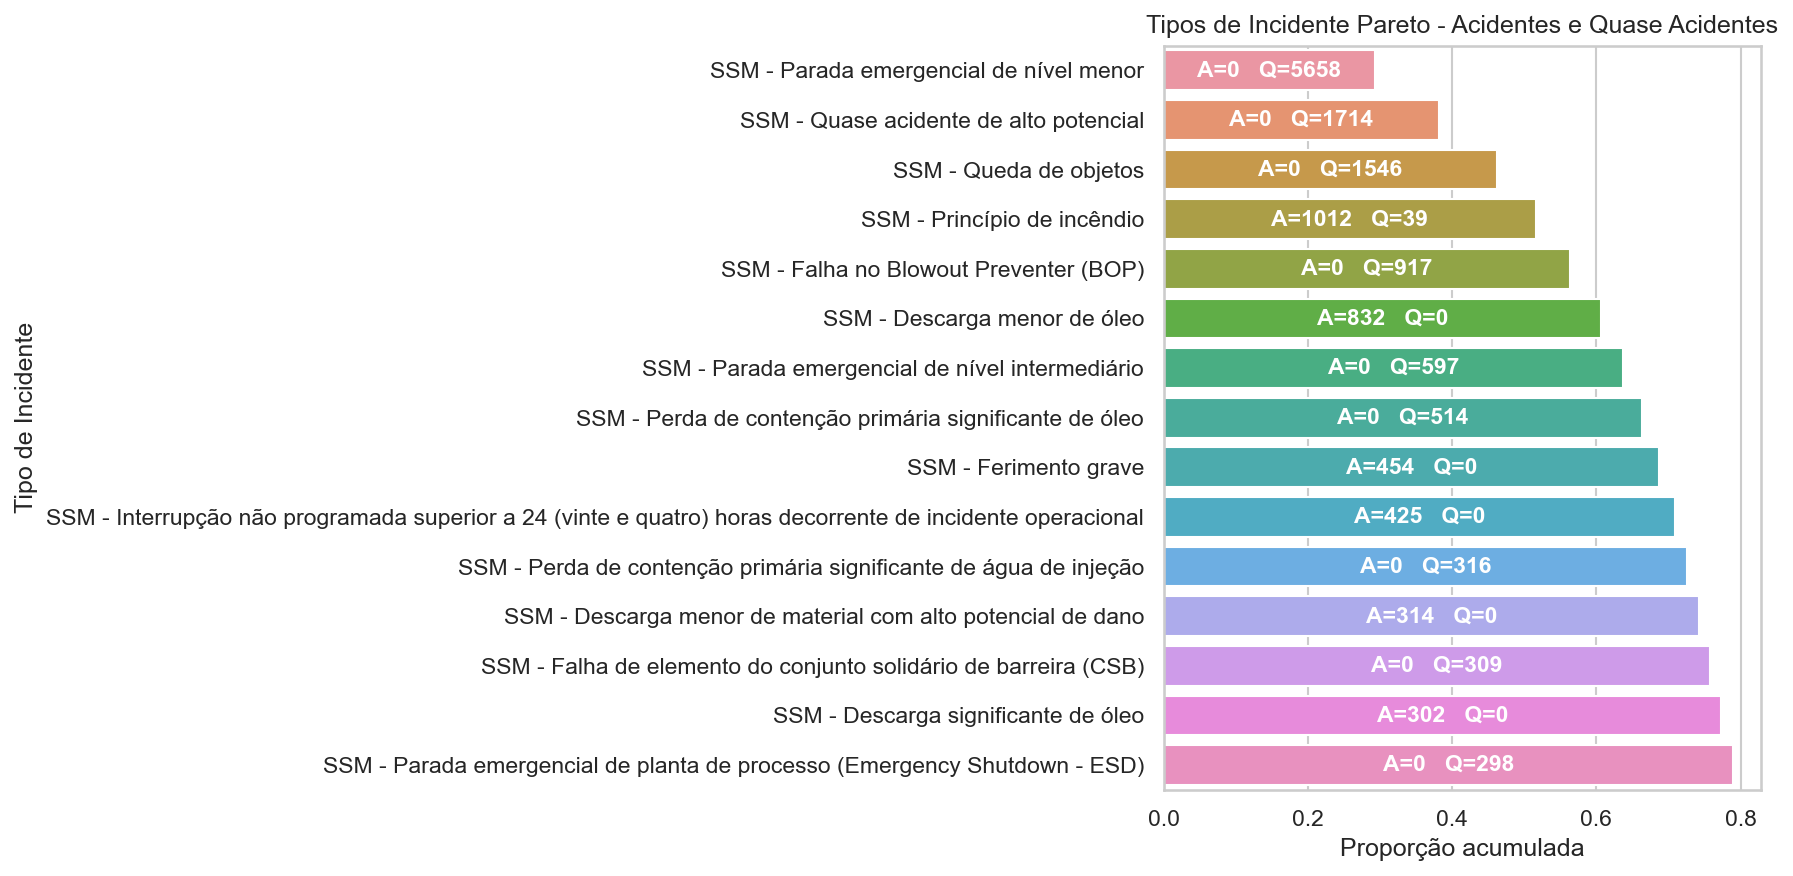

In [81]:
# ===============================
#  PREPARAÇÃO DOS DADOS
# ===============================

# contagem total para Pareto
contagem = df_filtrado['Tipo_de_incidente'].value_counts()
percentual = contagem / contagem.sum()
acumulado = percentual.cumsum()

# mantém itens até 80%
pareto = acumulado[acumulado <= 0.8]

# contagem A/Q
tabela_aq = (
    df_filtrado.groupby(['Tipo_de_incidente', 'DSC_QUASE_ACIDENTE_ACIDENTE'])
    .size()
    .unstack(fill_value=0)
)

tabela_aq = tabela_aq.reindex(columns=['Acidente', 'Quase acidente'], fill_value=0)

# ===============================
#  GRÁFICO
# ===============================

plt.figure(figsize=(12, 6))

sns.barplot(
    x=pareto.values,
    y=pareto.index,
    orient='h'
)

for i, categoria in enumerate(pareto.index):

    valor_acumulado = pareto[categoria]

    # Quantidades
    qtd_A = tabela_aq.loc[categoria, 'Acidente']
    qtd_Q = tabela_aq.loc[categoria, 'Quase acidente']

    texto = f"A={qtd_A}   Q={qtd_Q}"

    # Centralizar no meio da barra acumulada
    posicao_x = valor_acumulado / 2

    plt.text(
        posicao_x,
        i,
        texto,
        ha='center',
        va='center',
        color='white',
        fontsize=11,
        fontweight='bold'
    )

plt.xlabel('Proporção acumulada')
plt.ylabel('Tipo de Incidente')
plt.title('Tipos de Incidente Pareto - Acidentes e Quase Acidentes')
plt.tight_layout()

# Salvar em arquivo
#plt.savefig("graficos/Tipos de Incidente - Pareto com A e Q.png", dpi=600, bbox_inches='tight')

fig = plt.gcf()
fig.savefig(
    "graficos/Tipos de Incidente Pareto - Acidentes e Quase Acidentes.png", 
    dpi=600, 
    bbox_inches='tight', 
    transparent=True
)

plt.show()

## Impacto Financeiro

### Acidente vs Quase acidente

In [57]:
# Soma do custo
totais_valor = (
    df_filtrado
    .groupby('DSC_QUASE_ACIDENTE_ACIDENTE')['Custo_Incidente']
    .sum()
)

# Quantidade de registros
totais_qtd = (
    df_filtrado
    .groupby('DSC_QUASE_ACIDENTE_ACIDENTE')['Custo_Incidente']
    .count()
)

# Formatação do valor (sem notação científica)
totais_valor_formatado = (
    totais_valor
    .apply(lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
)

# Combina tudo em uma tabela final
resultado = pd.DataFrame({
    'Quantidade': totais_qtd,
    'Custo Total': totais_valor_formatado
})

resultado

,Quantidade,Custo Total
DSC_QUASE_ACIDENTE_ACIDENTE,,
Acidente,6017,"R$ 6.302.093.430,00"
Quase acidente,13310,"R$ 1.834.811.080,00"


In [58]:
custo_medio_acidente = 6123669430 / 6017
custo_medio_quase = 1834811080 / 13310
relacao = custo_medio_acidente / custo_medio_quase
print(f"O acidente é {relacao:.2f} vezes mais caro que o quase acidente.")

O acidente é 7.38 vezes mais caro que o quase acidente.


### Impacto Financeiro - Tipo de Gravidade

In [59]:
# Soma do custo por gravidade
totais_valor = df.groupby('DSC_GRAVIDADE_TIPO')['Custo_Incidente'].sum()

# Quantidade de incidentes por gravidade
totais_qtd = df.groupby('DSC_GRAVIDADE_TIPO')['Custo_Incidente'].count()

# Custo médio por gravidade
custo_medio = totais_valor / totais_qtd

# Formatação do valor total
totais_valor_formatado = totais_valor.apply(
    lambda x: f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

# Combina tudo em uma tabela final
resultado_gravidade = pd.DataFrame({
    'Quantidade': totais_qtd,
    'Custo Total': totais_valor_formatado,
    'Custo Médio': custo_medio
})

print(resultado_gravidade)

# Comparações de custo médio
relacao_moderado_leve = custo_medio['MODERADO'] / custo_medio['LEVE']
relacao_grave_leve = custo_medio['GRAVE'] / custo_medio['LEVE']
relacao_grave_moderado = custo_medio['GRAVE'] / custo_medio['MODERADO']

print(f"O incidente MODERADO é {relacao_moderado_leve:.2f} vezes mais caro que o LEVE.")
print(f"O incidente GRAVE é {relacao_grave_leve:.2f} vezes mais caro que o LEVE.")
print(f"O incidente GRAVE é {relacao_grave_moderado:.2f} vezes mais caro que o MODERADO.")

                    Quantidade          Custo Total   Custo Médio
DSC_GRAVIDADE_TIPO                                               
GRAVE                      233  R$ 4.307.325.059,00  1.848637e+07
LEVE                     22720  R$ 1.416.723.928,00  6.235581e+04
MODERADO                  2693  R$ 2.412.861.842,00  8.959754e+05
O incidente MODERADO é 14.37 vezes mais caro que o LEVE.
O incidente GRAVE é 296.47 vezes mais caro que o LEVE.
O incidente GRAVE é 20.63 vezes mais caro que o MODERADO.


### Impacto Financeiro - Categoria de Custo

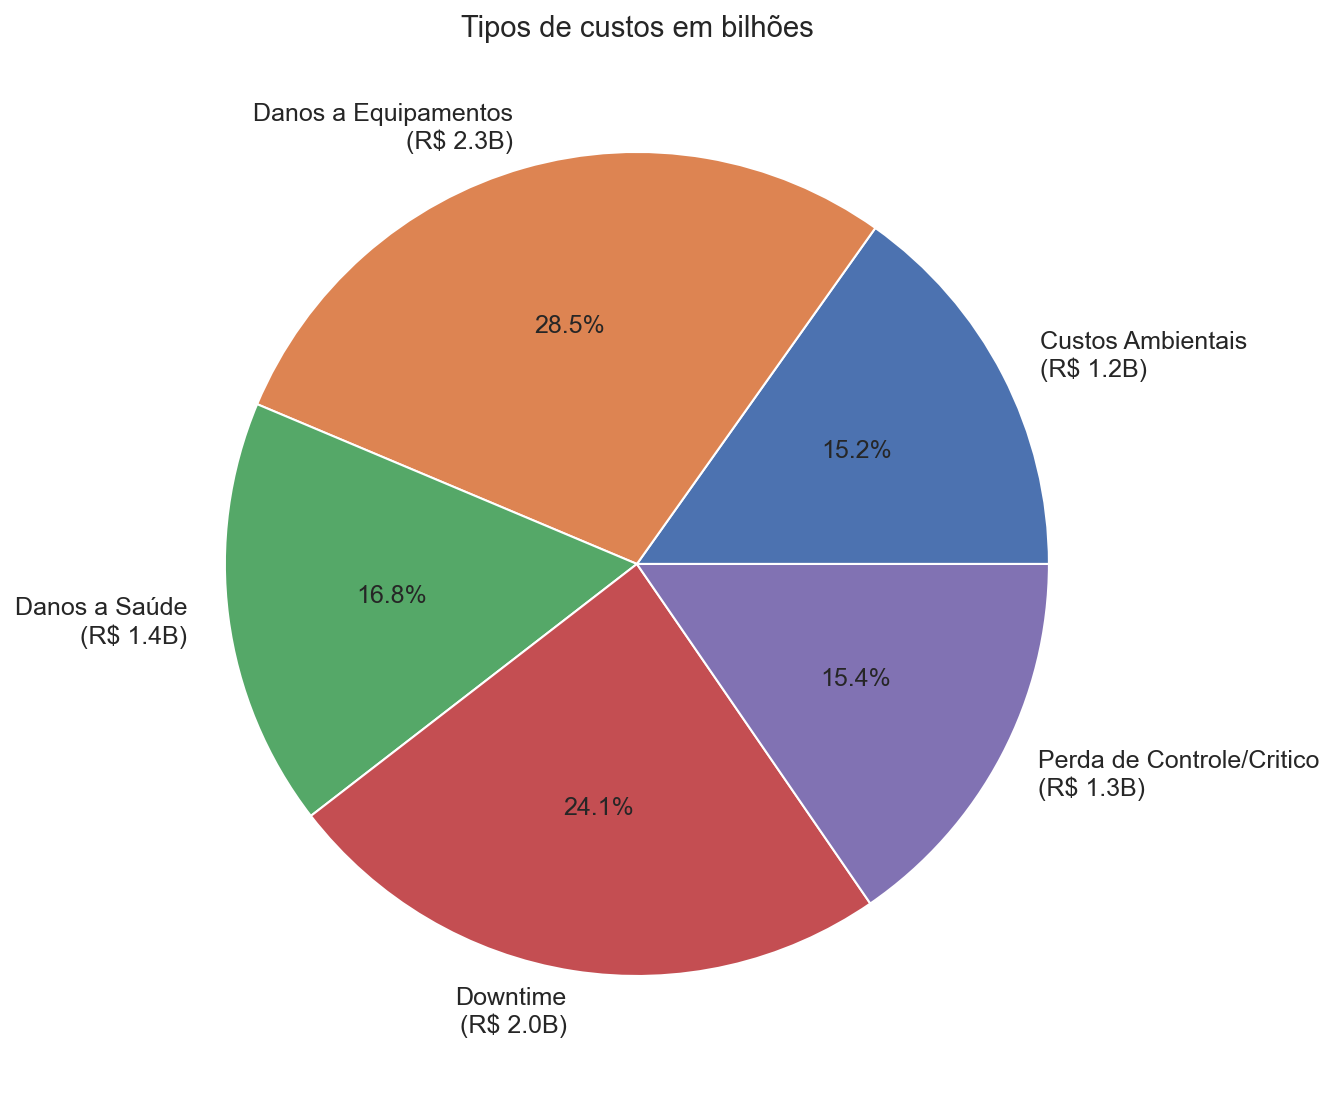

In [77]:
# Função para formatar valores monetários em formato reduzido
def formatar_reduzido(valor):
    if valor >= 1_000_000_000:
        return f"R$ {valor/1_000_000_000:.1f}B"
    elif valor >= 1_000_000:
        return f"R$ {valor/1_000_000:.1f}M"
    elif valor >= 1_000:
        return f"R$ {valor/1_000:.1f}k"
    else:
        return f"R$ {valor:.0f}"

# Aplica estilo seaborn
sns.set_theme(style="whitegrid")

# Remove "Não Classificado"
df_pizza = df[df["Categoria_Custo"] != "Não Classificado"]

# Agrupa valores
data = df_pizza.groupby("Categoria_Custo")["Custo_Incidente"].sum()

# Labels: categoria + valor reduzido
labels = [f"{cat}\n({formatar_reduzido(val)})" for cat, val in data.items()]

# Criação do gráfico
fig, ax = plt.subplots(figsize=(9, 9))

ax.pie(
    data.values,
    labels=labels,
    autopct='%1.1f%%',
    textprops={'fontsize': 12}
)

ax.set_title("Tipos de custos em bilhões", fontsize=14)
plt.tight_layout()

# Salvar em arquivo
#plt.savefig("graficos/Distribuição de Custo por Categoria de Custo.png", dpi=600, bbox_inches='tight')

fig = plt.gcf()
fig.savefig(
    "graficos/Distribuição de Custo por Categoria de Custo.png", 
    dpi=600, 
    bbox_inches='tight', 
    transparent=True
)

plt.show()

### Impacto Financeiro - Instalação

#### Potenciais clientes para focar em segurança

C:\Users\Bill_\AppData\Local\Temp/ipykernel_11312/632693712.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([formatar_reduzido(x) for x in ax.get_xticks()])


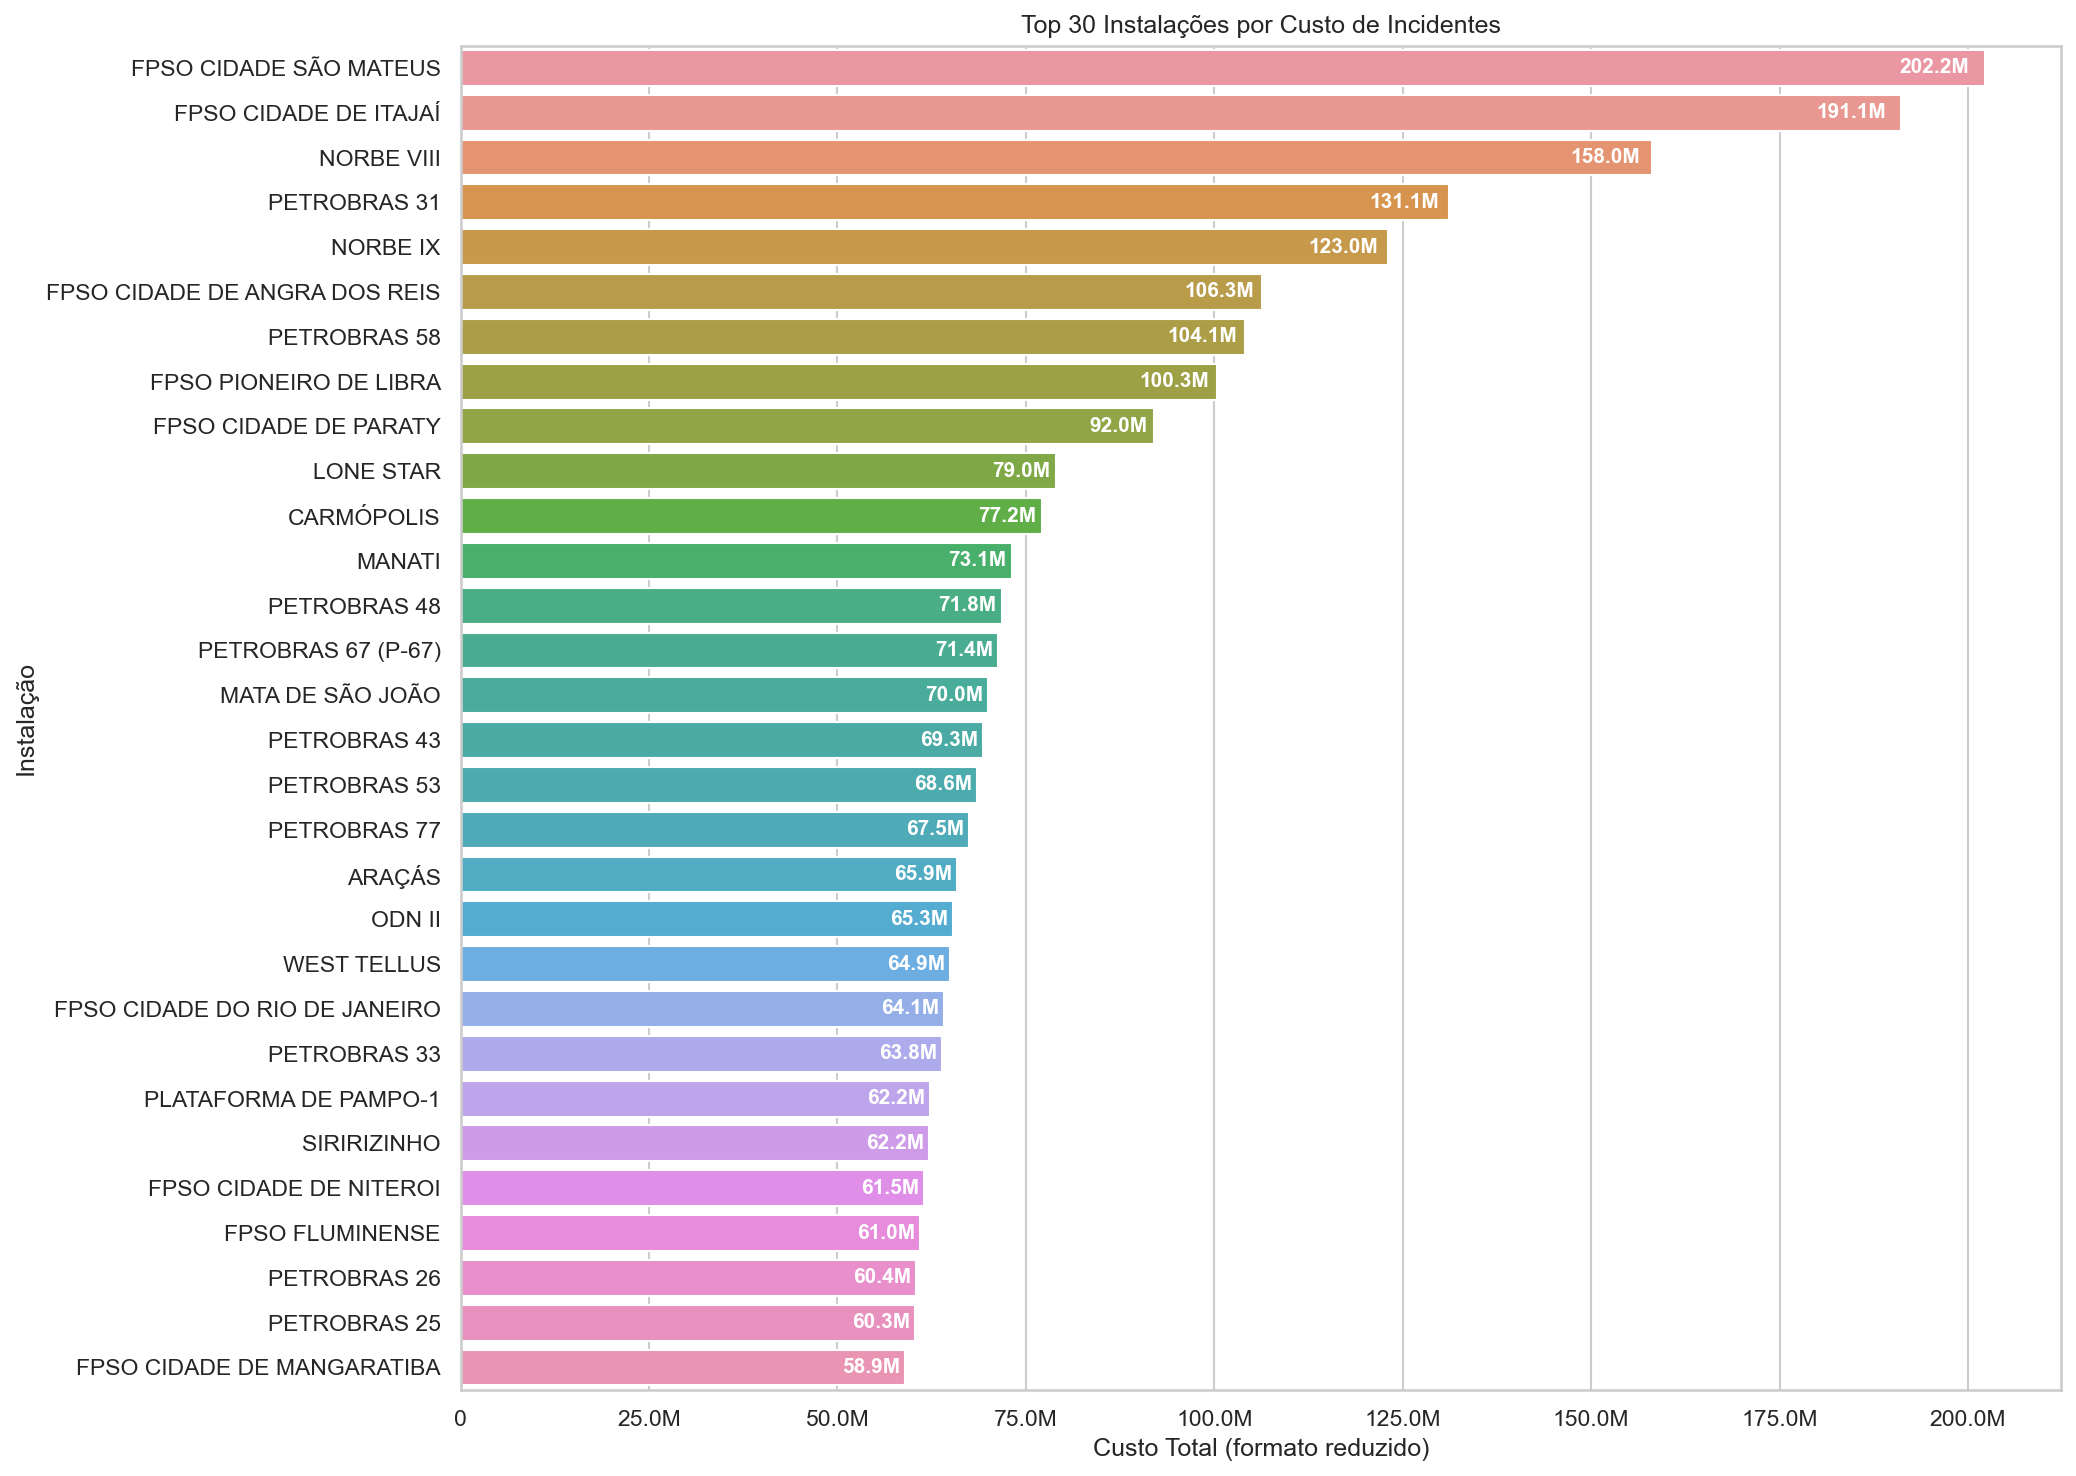

In [74]:
# Função para formatar valores grandes
def formatar_reduzido(valor):
    if valor >= 1_000_000_000:
        return f"{valor/1_000_000_000:.1f}B"
    elif valor >= 1_000_000:
        return f"{valor/1_000_000:.1f}M"
    elif valor >= 1_000:
        return f"{valor/1_000:.1f}k"
    else:
        return str(int(valor))

# Agrupa e seleciona o Top 30
top_inst = (
    df.groupby("Instalacao")["Custo_Incidente"]
    .sum()
    .sort_values(ascending=False)
    .head(30)
    .reset_index()
)

plt.figure(figsize=(14, 10))
ax = sns.barplot(
    data=top_inst,
    x="Custo_Incidente",
    y="Instalacao"
)

# Adiciona valores dentro das barras
for i, row in top_inst.iterrows():
    valor_fmt = formatar_reduzido(row["Custo_Incidente"])
    ax.text(
        row["Custo_Incidente"] * 0.99,   # posição horizontal
        i,                               # posição vertical
        valor_fmt,
        ha='right',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

# Eixo X em formato reduzido
ax.set_xticklabels([formatar_reduzido(x) for x in ax.get_xticks()])

plt.title("Top 30 Instalações por Custo de Incidentes")
plt.xlabel("Custo Total (formato reduzido)")
plt.ylabel("Instalação")
plt.tight_layout()

# Salvar em arquivo
#plt.savefig("graficos/Top 30 Instalações por Custo de Incidentes.png", dpi=600, bbox_inches='tight')

fig = plt.gcf()
fig.savefig(
    "graficos/Top 30 Instalações por Custo de Incidentes.png", 
    dpi=600, 
    bbox_inches='tight', 
    transparent=True
)

plt.show()

### Correlação entre as gravidades, média instalações

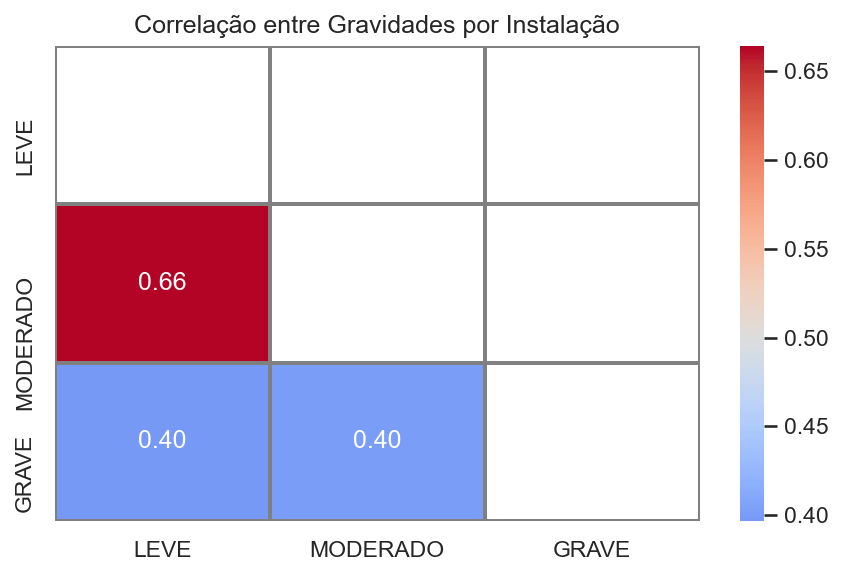

In [75]:
# Reordenar colunas e linhas
ordem = ["LEVE", "MODERADO", "GRAVE"]
corr_ord = corr.loc[ordem, ordem]

# Criar máscara para esconder diagonal + triângulo superior
mask = np.triu(np.ones_like(corr_ord, dtype=bool))

plt.figure(figsize=(6,4))
sns.heatmap(
    corr_ord,
    annot=True,
    mask=mask,
    cmap='coolwarm',
    center=0.5,
    linewidths=1,
    linecolor='gray',
    fmt=".2f",
    cbar=True
)

# Remover nomes dos eixos
plt.xlabel("")
plt.ylabel("")

plt.title("Correlação entre Gravidades por Instalação")
plt.tight_layout()

fig = plt.gcf()
fig.savefig(
    "graficos/Correlação entre Gravidades por Instalação.png", 
    dpi=600, 
    bbox_inches='tight', 
    transparent=True
)

plt.show()

### Impacto Financeiro - Tipo de Incidente

C:\Users\Bill_\AppData\Local\Temp/ipykernel_11312/3590444410.py:32: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([formatar_reduzido(x) for x in ax.get_xticks()])


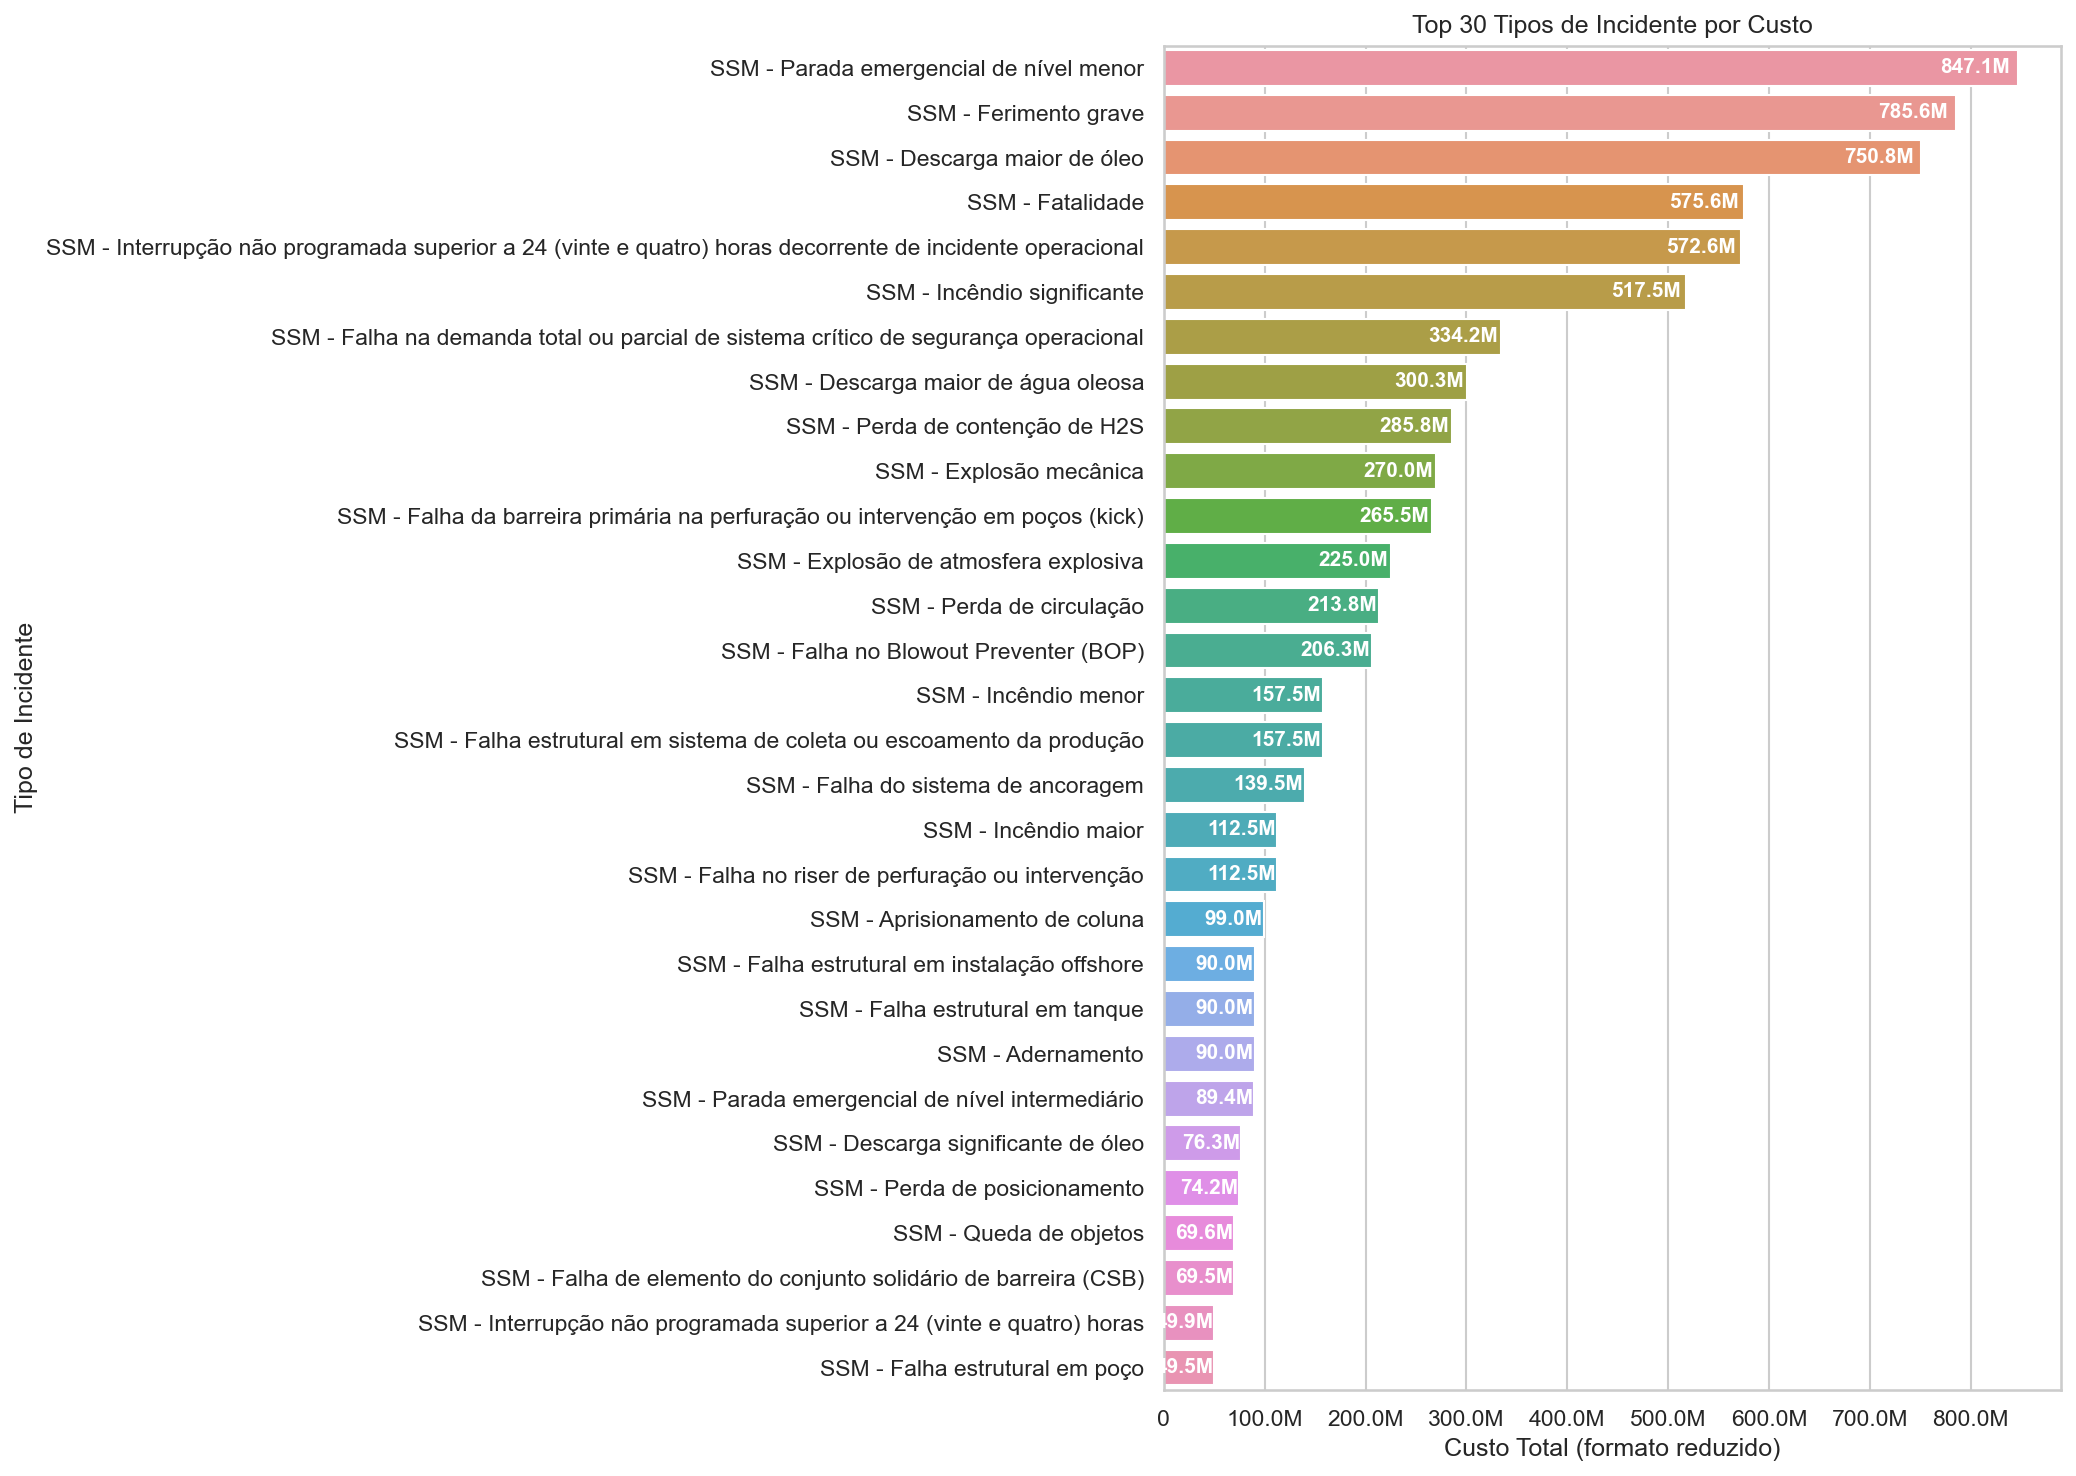

In [76]:
# Agrupa por tipo de incidente e pega o Top 30
top_tipos = (
    df.groupby("Tipo_de_incidente")["Custo_Incidente"]
    .sum()
    .sort_values(ascending=False)
    .head(30)
    .reset_index()
)

plt.figure(figsize=(14, 10))
ax = sns.barplot(
    data=top_tipos,
    x="Custo_Incidente",
    y="Tipo_de_incidente"
)

# Adiciona valores dentro das barras
for i, row in top_tipos.iterrows():
    valor_fmt = formatar_reduzido(row["Custo_Incidente"])
    ax.text(
        row["Custo_Incidente"] * 0.99,   # Posição horizontal
        i,                               # Posição vertical
        valor_fmt,
        ha='right',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

# Eixo X em formato reduzido
ax.set_xticklabels([formatar_reduzido(x) for x in ax.get_xticks()])

plt.title("Top 30 Tipos de Incidente por Custo")
plt.xlabel("Custo Total (formato reduzido)")
plt.ylabel("Tipo de Incidente")
plt.tight_layout()

# Salvar em arquivo
#plt.savefig("graficos/Top 30 Tipos de Incidente por Custo.png", dpi=600, bbox_inches='tight')

fig = plt.gcf()
fig.savefig(
    "graficos/Top 30 Tipos de Incidente por Custo.png", 
    dpi=600, 
    bbox_inches='tight', 
    transparent=True
)

plt.show()

In [64]:
print("Todos blocos foram executados")

Todos blocos foram executados


In [65]:
df

,Numero,CNPJ,Instalacao,Tipo_Instalacao_Detalhado,Proprietario_Instalacao,Fonte_Classificacao,Data_de_criacao,DataHora_primeira_observacao,DataHora_incidente,Tipo_de_incidente,Categoria_Custo,Custo_Incidente,DSC_GRAVIDADE_TIPO,DSC_QUASE_ACIDENTE_ACIDENTE,Numero_de_feridos_graves,Numero_de_fatalidades
0,1307/000022,08926302000105,Ocean Quest,Navio de apoio logístico,Não identificado,Classificação avançada (confiança: Média) - Fr...,2013-07-09,2013-06-26 18:20:00,2013-06-26 18:20:00,SSM - Ferimento grave,Danos a Saúde,249750.0,MODERADO,Acidente,1,0
1,1307/000023,33000167000101,Cerrado,Outro,Não identificado,Classificação avançada (confiança: Muito Baixa...,2013-07-10,2013-07-06 07:20:00,2013-07-06 07:20:00,SSM - Ferimento grave,Danos a Saúde,249750.0,MODERADO,Acidente,1,0
2,1307/000025,33000167000101,Ocean-Rig Corcovado,Sonda de Perfuração,Ocean Rig,https://pt.linkedin.com/posts/venicio-viter-a7...,2013-07-11,2013-07-09 12:45:00,2013-07-09 12:45:00,SSM - Princípio de incêndio,Danos a Equipamentos,45000.0,LEVE,Acidente,0,0
3,1307/000026,33000167000101,OCEAN ALLIANCE,Navio de apoio logístico,Não identificado,Classificação avançada (confiança: Média) - Fr...,2013-07-11,2013-07-09 18:20:00,2013-07-09 18:20:00,SSM - Ferimento grave,Danos a Saúde,249750.0,MODERADO,Acidente,1,0
4,1307/000027,33000167000101,SS AMAZÔNIA,Sonda de perfuração,Baerfield Drilling LLC,https://www.gov.br/mme/pt-br/arquivos/do-29-09...,2013-07-12,2013-06-28 16:30:00,2013-06-28 16:30:00,SSM - Descarga menor de óleo,Custos Ambientais,3000.0,LEVE,Acidente,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25641,2309/000219,09347916000197,FPSO CIDADE DE ITAJAÍ,FPSO,SBM Offshore (afretado pela Petrobras),https://www.sbmoffshore.com/,2023-09-29,2023-05-29 10:35:00,2023-05-29 10:35:00,SSM - Falha estrutural em tanque,Danos a Equipamentos,22500000.0,GRAVE,Acidente,0,0
25642,2309/000219,09347916000197,FPSO CIDADE DE ITAJAÍ,FPSO,SBM Offshore (afretado pela Petrobras),https://www.sbmoffshore.com/,2023-09-29,2023-05-29 10:35:00,2023-05-29 10:35:00,SSM - Perda de contenção primária maior de águ...,Custos Ambientais,3000.0,LEVE,Quase acidente,0,0
25643,2501/000230,35723994000159,SÃO MATEUS LESTE,Outro,Não identificado,Classificação avançada (confiança: Muito Baixa...,2025-01-30,2023-06-05 08:00:00,2023-06-05 07:50:00,SSM - Descarga significante de óleo,Custos Ambientais,252500.0,MODERADO,Acidente,0,0
25644,2501/000230,35723994000159,SÃO MATEUS LESTE,Outro,Não identificado,Classificação avançada (confiança: Muito Baixa...,2025-01-30,2023-06-05 08:00:00,2023-06-05 07:50:00,SSM - Perda de contenção primária significante...,Custos Ambientais,3000.0,LEVE,Quase acidente,0,0
